# Loan Default Risk Modelling

This notebook builds a credit risk model to predict whether a professional loan applicant is likely to default within a 24-month period.

## Business context
The goal is to support the bank's credit approval process by building an application score that flags higher-risk borrowers before a loan is granted. In practice, this helps reduce credit losses and improve portfolio quality.

## Project objective
- Understand the structure of the credit dataset
- Identify the most informative variables for default prediction
- Clean and prepare the data for modelling
- Compare several classifiers
- Select the best-performing model and generate risk scores for unseen applications

## Important note
The raw dataset cannot be shared publicly because of an NDA. This notebook therefore focuses on the modelling workflow, feature engineering decisions, and evaluation logic used during the challenge.


In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso, LassoCV
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

from sklearn.ensemble import HistGradientBoostingClassifier


In [2]:
df = pd.read_csv(r"DSC_training.csv") # read data to DataFrame
y1 = df.iloc[:,-1] # pandas Series containing the target variable
y = df.iloc[:,-1].values # numpy array containing the target variable

## 1. Data understanding

We also identify variables with a strong relationship to annual income, since income is a key financial driver in credit risk and is used later for missing value imputation.

This section explores the structure of the training dataset and checks the relationships between variables.

The goal is to understand which features are likely to be most predictive of default and whether there are strong correlations or redundant variables that should be handled before modelling.

### Feature correlation analysis

This helps us detect duplicated information and understand which financial or behavioural indicators move together.

The next code block computes the correlation matrix for the numerical variables and prints the strongest positive and negative correlations.

In [3]:
#Now I will save seperately those which have categorical and numerical data
columns_to_encode = df.select_dtypes(include=['object']).columns
numerical_columns = [col for col in df if col not in columns_to_encode]
#To identify and print pairs of features that are highly correlated along with their respective correlation coefficients

# Calculate the correlation matrix
correlation_matrix = df[numerical_columns].corr()
# Create a mask to filter out redundant pairs (i.e., keep only upper triangle)
correlation_matrix = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Filter correlations based on the threshold
threshold = 0.5
positive_correlations = correlation_matrix.stack()[correlation_matrix.stack() > threshold]  # Only positive correlations > 0.5
negative_correlations = correlation_matrix.stack()[correlation_matrix.stack() < -threshold]  # Only negative correlations < -0.5

# Print positive correlations
print("**Positively Correlated Features**")
for (feature1, feature2), corr_value in positive_correlations.items():
    print(f"{feature1} is positively correlated ({corr_value:.2f}) with {feature2}")

# Print negative correlations
print("\n**Negatively Correlated Features**")
for (feature1, feature2), corr_value in negative_correlations.items():
    print(f"{feature1} is negatively correlated ({corr_value:.2f}) with {feature2}")
    
    

**Positively Correlated Features**
APPLICANTS_CNT is positively correlated (0.87) with NR_APPLICANTS_WITH_INCOME
COLLATERAL_AMT is positively correlated (1.00) with REAL_ESTATE_VALUE_AMT
CREDIT_INTER_PRIV_PERIODIC_MTHS is positively correlated (1.00) with DEBET_INTER_PRIV_PERIODIC_MTHS
CREDIT_INTER_PROF_PERIODIC_MTHS is positively correlated (1.00) with DEBET_INTER_PROF_PERIODIC_MTHS
EXP_WITH_CUSTOMER_CD is positively correlated (0.52) with BEH_SCORE_AVG_A3
EXST_CHRG_PRFCRED_AMT is positively correlated (1.00) with TOT_OPEN_CREDITS_AMT
EXST_CHRG_PRFCRED_AMT is positively correlated (1.00) with MONTHLY_HOUSING_AMT_max
EXST_CHRG_PRFCRED_AMT is positively correlated (1.00) with TOT_OPEN_CREDITS_AMT_max
KPI_CASH_FLOW_AMT is positively correlated (0.79) with PROFIT_BEFORE_TAX_AMT
KPI_CASH_FLOW_AMT is positively correlated (0.70) with WRITE_OFF_YEAR_AMT
LOSS_YEAR_AMT is positively correlated (0.58) with POSIT_TRANS_COREPROF_CNT_avg
LOSS_YEAR_AMT is positively correlated (0.55) with TOT_CRE_I

In [4]:
#Goal is to find the features that are above 0.3 correlated to 'ANNUAL_INCOME_AMT_avg' and then try to predict the missing values of 'ANNUAL_INCOME_AMT_avg' by using them
# Specify the target feature
target_feature = 'ANNUAL_INCOME_AMT_avg'
threshold = 0.3
correlation_matrix = df[numerical_columns].corr()
# Filter correlations for the target feature
target_correlations = correlation_matrix[target_feature]
# Find features with absolute correlation above the threshold
high_correlations = target_correlations[abs(target_correlations) > threshold].sort_values(key=abs, ascending=False)
# Create a DataFrame for the results
correlation_table = pd.DataFrame({
    'Feature': high_correlations.index,
    'Absolute Correlation': high_correlations.abs().values
})
# Display the correlation table
print(correlation_table)

                 Feature  Absolute Correlation
0  ANNUAL_INCOME_AMT_avg              1.000000
1       BEH_SCORE_MIN_A3              0.839970
2       BEH_SCORE_AVG_A3              0.746720
3      KPI_CASH_FLOW_AMT              0.424154
4  PROFIT_BEFORE_TAX_AMT              0.395237


In [5]:
#This class will be used to predict missing values for the Income feature
class RegressionImputer(BaseEstimator, TransformerMixin):
    def __init__(self, target_col, regressor_features):
        self.target_col = target_col
        self.regressor_features = regressor_features
        self.model = LinearRegression()
    
    def fit(self, X, y=None):
        # Fit regression model only on rows where target_col is not NaN
        train_data = X[~X[self.target_col].isna()]
        self.model.fit(train_data[self.regressor_features], train_data[self.target_col])
        return self

    def transform(self, X):
        # Predict missing values in target_col
        X = X.copy()
        missing_data = X[X[self.target_col].isna()]
        if not missing_data.empty:
            X.loc[missing_data.index, self.target_col] = self.model.predict(missing_data[self.regressor_features])
        return X
    
    def get_feature_names_out(self, input_features=None):
        # Return the original column names
        return input_features if input_features is not None else list(self.regressor_features) + [self.target_col]



In [6]:
class WeightOfEvidenceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, target_column):
        self.target_column = target_column
        self.woe_dict = {}
        self.feature_names = []

    def fit(self, X, y=None):
        # Convert to DataFrame
        X = pd.DataFrame(X).copy()
        X[self.target_column] = y
       
        # Calculate WoE for each column
        for col in X.drop(columns=self.target_column).columns:
            col_summary = X.groupby(col)[self.target_column].agg(
                positive=lambda x: (x == 1).sum(),
                negative=lambda x: (x == 0).sum()
            )
            col_summary['total'] = col_summary['positive'] + col_summary['negative']
            col_summary['dist_positive'] = col_summary['positive'] / col_summary['positive'].sum()
            col_summary['dist_negative'] = col_summary['negative'] / col_summary['negative'].sum()
            col_summary['woe'] = np.log(col_summary['dist_positive'] / col_summary['dist_negative'])
           
            # Store WoE mapping for the column
            self.woe_dict[col] = col_summary['woe'].to_dict()
            self.feature_names.append(f"{col}_woe")
        return self

    def transform(self, X):
        # Convert to DataFrame
        X = pd.DataFrame(X).copy()
       
        # Replace values with WoE
        for col in X.columns:
            if col in self.woe_dict:
                X[col] = X[col].map(self.woe_dict[col])
        return X

    def get_feature_names_out(self, input_features=None):
        return self.feature_names

## 2. Feature engineering

These engineered features are intended to reflect the real economic meaning behind the raw account data rather than relying only on the original columns.

Credit risk models often improve when we construct meaningful variables from the raw fields. In this section we create proxy variables that capture loan burden, borrower age, tenure, and other financial health indicators.

In [7]:
df['APPLICATION_DT'] = pd.to_datetime(df['APPLICATION_DT']) #application date
df['MATURITY_DT'] = pd.to_datetime(df['MATURITY_DT']) # maturity date
df['birth_dt_A1'] = pd.to_datetime(df['birth_dt_A1']) # YOB_1
df['birth_dt_A2'] = pd.to_datetime(df['birth_dt_A2']) # YOB_2
df['birth_dt_A3'] = pd.to_datetime(df['birth_dt_A3']) # YOB_3


df["tenure"] = df.apply(
    lambda row: (row['MATURITY_DT'] - row['APPLICATION_DT']).days / 365.25, axis=1
)
df["age1"] = df.apply(
    lambda row: (row['APPLICATION_DT'] - row['birth_dt_A1']).days / 365.25, axis=1
)
df["age2"] = df.apply(
    lambda row: (row['APPLICATION_DT'] - row['birth_dt_A2']).days / 365.25, axis=1
)
df["age3"] = df.apply(
    lambda row: (row['APPLICATION_DT'] - row['birth_dt_A3']).days / 365.25, axis=1
)

df['application_month'] = df.apply(
    lambda row: (row['APPLICATION_DT']).month, axis=1
    )

df.drop(columns=['year','IN_DEFAULT_FLG','birth_dt_A1', 'birth_dt_A2', 'birth_dt_A3', 'MATURITY_DT', 'APPLICATION_DT', 'APPLICATION_BY_EMPLOYEE_FLG'], inplace=True)



## 3. Data preprocessing

The objective is to make the dataset suitable for machine learning while preserving the original business meaning of the credit features.

Before training a model, the raw dataset must be aligned into a consistent structure. This stage includes splitting categorical fields, converting data types, creating binary indicators, and removing fields that are no longer useful.

In [8]:
df[["cat_profession_1", "cat_profession_2"]] = df["PROFESSION_CAT"].str.split("-", expand=True)
df[["cat_ed_1", "cat_ed_2"]] = df["CAT_EDUCATION_LEVEL_CD"].str.split("-", expand=True)
df[["cat_empl_1", "cat_empl_2"]] = df["EMPLOYMENT_STATUS_CD"].str.split("-", expand=True)
df[["cat_res_1", "cat_res_2"]] = df["CAT_RESIDENT_STATUS_CD"].str.split("-", expand=True)
df[["cat_inc_src_1", "cat_inc_src_2"]] = df["CAT_INCOME_SRC_CD"].str.split("-", expand=True)
df[["cat_inc_rep_1", "cat_inc_rep_2"]] = df["CAT_REP_INCOME_SRC_CD"].str.split("-", expand=True)
df[["cat_mar_1", "cat_mar_2"]] = df["COMB_MARITAL_STATUS"].str.split("-", expand=True)


df.drop(columns=['CREDIT_TYPE_CD', "PROFESSION_CAT",'CAT_EDUCATION_LEVEL_CD','EMPLOYMENT_STATUS_CD', "CAT_RESIDENT_STATUS_CD","CAT_INCOME_SRC_CD", "CAT_REP_INCOME_SRC_CD",'COMB_MARITAL_STATUS','TOT_DOM_EXC_CRE_INT_PRIV_AMT_max','TOT_DOM_EXC_CRE_INT_PRIV_CNT_max','TOT_DOM_EXC_CRE_INT_PROF_AMT_max','TOT_DOM_EXC_CRE_INT_PROF_CNT_max'], inplace=True)


In [9]:
df['is_be'] = np.where(df['nationality_A1'] == 'B', 1, 0) 

#fill missing values
df['mnths_in_business_flg'] = np.where(pd.notna(df['MTHS_IN_BUSINESS_CNT']), 1, 0) 
df.drop(columns=['MTHS_IN_BUSINESS_CNT'], inplace=True)

df['mnths_in_be'] = np.where(pd.notna(df['MONTHS_IN_BELGIUM_CNT_min']), 1, 0) 
df.drop(columns=['MONTHS_IN_BELGIUM_CNT_min'], inplace=True)


In [10]:
#before filling the 'MORTGAGE_ON_REAL_ESTATE_FLG', we need to perform a check
#when feature 'REAL_ESTATE_VALUE_AMT' has a value and 'MORTGAGE_ON_REAL_ESTATE_FLG' is NaN, we make it 1 else we leave it as is
df['MORTGAGE_ON_REAL_ESTATE_FLG'] = np.where(df['MORTGAGE_ON_REAL_ESTATE_FLG'].isna() & df['REAL_ESTATE_VALUE_AMT'].notna(), 1, df['MORTGAGE_ON_REAL_ESTATE_FLG'])
#when feature 'REAL_ESTATE_VALUE_AMT' has a value and 'MORTGAGE_ON_REAL_ESTATE_FLG' is 0, we make it 1 else we leave it as is
df['MORTGAGE_ON_REAL_ESTATE_FLG'] = np.where(df['MORTGAGE_ON_REAL_ESTATE_FLG'] == 0 & df['REAL_ESTATE_VALUE_AMT'].notna(), 1, df['MORTGAGE_ON_REAL_ESTATE_FLG'])

CREATE NEW FEATURES

In [11]:
#to adrress DataFrame fragmented warning, we write to the below df, and at the end concat with original df
df_tmp = pd.DataFrame()
#Debt-to-income
df_tmp['dti_1'] = (df['APPLIED_AMT']+df['OTH_BANKS_CREDITS_AMT']) /df['ANNUAL_INCOME_AMT_avg']
df_tmp['dti_2'] = (df['APPLIED_AMT']+df['TOT_OPEN_CREDITS_AMT']) /df['ANNUAL_INCOME_AMT_avg']
df_tmp['dti_3'] = np.where(df['OTH_BANKS_CREDITS_AMT'] < df['TOT_OPEN_CREDITS_AMT'], df_tmp['dti_2'], df_tmp['dti_1']) # if condition is true, I want to keep dti_2, else keep dti_1

#df_tmp['dti'] = (df['APPLIED_AMT']+df[['OTH_BANKS_CREDITS_AMT', 'TOT_OPEN_CREDITS_AMT']].max(axis=1)) /df['ANNUAL_INCOME_AMT_avg']

#Loan-to-Value Ratio(LTV)
df_tmp['LTV']=df['APPLIED_AMT']/df['COLLATERAL_AMT']

#Debt service coverage ratio
df_tmp['DSCR']=df['KPI_CASH_FLOW_AMT']/df['KPI_REPAYM_CAP_AMT']

#Credit utilization rate
df_tmp['CUR1']=df['TOT_OPEN_CREDITS_AMT']/df['TOT_CRED_LINE_COREPRIV_AMT_max']
df_tmp['CUR2']=df['TOT_OPEN_CREDITS_AMT']/df['TOT_CRED_LINE_COREPROF_AMT_max']

#SAVINGS CUSHION RATE
df_tmp['SCR']=df['AVG_POS_SALDO_SAVINGS_12_AMT_avg']/df['APPLIED_AMT']

#PROPORTION OF OVERDRAWN DAYS

df_tmp['overdrawn_days3priv']= df['OVERDRAWN_DAYS_PRIV_3_CNT_max']/3
df_tmp['overdrawn_days6priv']= df['OVERDRAWN_DAYS_PRIV_6_CNT_max']/6
df_tmp['overdrawn_days9priv']= df['OVERDRAWN_DAYS_PRIV_9_CNT_max']/9
df_tmp['overdrawn_days12priv']= df['OVERDRAWN_DAYS_PRIV_12_CNT_max']/12
df_tmp['overdrawn_days24priv']= df['OVERDRAWN_DAYS_PRIV_24_CNT_max']/24
df_tmp['overdrawn_days3prof']= df['OVERDRAWN_DAYS_PROF_3_CNT_max']/3
df_tmp['overdrawn_days6prof']= df['OVERDRAWN_DAYS_PROF_6_CNT_max']/6
df_tmp['overdrawn_days9prof']= df['OVERDRAWN_DAYS_PROF_9_CNT_max']/9
df_tmp['overdrawn_days12prof']= df['OVERDRAWN_DAYS_PROF_12_CNT_max']/12
df_tmp['overdrawn_days24prof']= df['OVERDRAWN_DAYS_PROF_24_CNT_max']/24

#Max Negative Balance/Income
df_tmp['Max_neg_balancetoincpriv']=df['AVG_NEG_SALDO_PRIV_12_AMT_max']/df['ANNUAL_INCOME_AMT_avg']
df_tmp['Max_neg_balancetoincprof']=df['AVG_NEG_SALDO_PROF_12_AMT_max']/df['ANNUAL_INCOME_AMT_avg']

#Average age 
df_tmp['avg_age']=df[['age1','age2','age3']].mean(axis=1)

#Dependents to Income Ratio
df_tmp['dependentstoinc']=df['DEPENDENTS_CNT_max']/df['ANNUAL_INCOME_AMT_avg']

df_tmp['age_at_maturity'] = np.where(df['FINANCIAL_PRODUCT_TYPE_CD'] == 'MTG', df['age1'] + df['tenure'], df['age1']) 


df = pd.concat([df,df_tmp],axis=1)


In [12]:
#some of the new variables (LTV for example) have been divided by 0, so we replace np.inf (infinity) with nan
df.replace({np.inf: np.nan}, inplace = True) 

df.replace({None: np.nan}, inplace = True)
df.replace({'': np.nan}, inplace = True)
df.replace({'NaN': np.nan}, inplace = True)

DATA PREPROCESSING

In [13]:
df["Nace_A1"] = df["Nace_A1"].astype(str)
df['nace'] = df['Nace_A1'].apply(lambda x: x[:2])
df['nace'] = np.where(df['nace']=='na','0',df['nace'])
df.drop(columns=['Nace_A1'], inplace=True)
#in the line above, we keep only the first two digits of the Nace classification

df['application_month'] = df['application_month'].astype(str)
df["Gender_A1"] = df["Gender_A1"].astype(str)
df["Gender_A2"] = df["Gender_A2"].astype(str)
df["Gender_A3"] = df["Gender_A3"].astype(str)
df["ACTIVE_CREDITS_FLG"] = df["ACTIVE_CREDITS_FLG"].astype(str)
df["MORTGAGE_ON_REAL_ESTATE_FLG"] = df["MORTGAGE_ON_REAL_ESTATE_FLG"].astype(str)
df["OTHER_REAL_ESTATE_FLG_max"] = df["OTHER_REAL_ESTATE_FLG_max"].astype(str)
df["EXP_WITH_CUSTOMER_CD"] = df["EXP_WITH_CUSTOMER_CD"].astype(str)

df['is_be'] = df['is_be'].astype(str)
df['mnths_in_business_flg'] = df['mnths_in_business_flg'].astype(str)
df['mnths_in_be'] = df['mnths_in_be'].astype(str)

In [14]:
#separate categorical from numerical columns
columns_to_encode = df.select_dtypes(include=['object']).columns
numerical_columns = [col for col in df if col not in columns_to_encode]

constant_columns = df[numerical_columns].loc[:, df[numerical_columns].std() == 0].columns
#print(f"Constant columns in train_num_df: {constant_columns}")
df.drop(columns=constant_columns, inplace=True)

columns_to_encode = df.select_dtypes(include=['object']).columns
numerical_columns = [col for col in df if col not in columns_to_encode]

## 4. Train/validation split

A validation set is especially useful when comparing candidate models and tuning hyperparameters.

The dataset is divided into training and validation subsets so the model can be evaluated on unseen data. This prevents overly optimistic results caused by training and testing on the same examples.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df, y1, test_size = 0.20, random_state = 0)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.25, random_state = 1)



In [16]:
cols_median = ['BEH_SCORE_AVG_A1','BEH_SCORE_MIN_A1','BEH_SCORE_AVG_A2','BEH_SCORE_MIN_A2','BEH_SCORE_AVG_A3','BEH_SCORE_MIN_A3','BEH_SCORE_AVG_AVG','BEH_SCORE_AVG_MIN','BEH_SCORE_MIN_AVG','BEH_SCORE_MIN_MIN']  # Fill with median
regressor_features = ['KPI_CASH_FLOW_AMT', 'PROFIT_BEFORE_TAX_AMT']
regressor_target = "ANNUAL_INCOME_AMT_avg"  # Target column for regression imputation
#woe_cols = ['nace','cat_empl_1','cat_empl_2', 'nationality_A1', 'nationality_A2']
#one_hot_cols = [col for col in columns_to_encode if col not in woe_cols]
#cols_zero = [col for col in df.columns if col not in columns_to_encode]

### Preprocessing pipeline

This is a standard and practical setup for credit scoring models, where both continuous and categorical features are important.

This section builds a preprocessing pipeline that handles numerical and categorical variables separately:

- Missing income values are imputed using a regression-based approach that uses correlated financial variables
- Numeric variables are imputed and scaled
- Categorical variables are imputed and one-hot encoded

In [17]:
# Define imputers and encoders
cat_imputer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])
'''
woe_transformer = WeightOfEvidenceTransformer(target_column='default')
woe_pipe = Pipeline([
    #("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("woe_transform", woe_transformer)
])
'''
numerical_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0)),
    ("scale", StandardScaler())
])

median_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])


In [18]:
# Combine into a column transformer
preprocessor = ColumnTransformer([
    ("median_fill", median_pipeline, cols_median),
    ("regression_impute", RegressionImputer(target_col=regressor_target, regressor_features=regressor_features), ['KPI_CASH_FLOW_AMT', 'PROFIT_BEFORE_TAX_AMT','ANNUAL_INCOME_AMT_avg']),
    #("zero_fill", zero_fill_imputer, numerical_columns),
    ("onehot", cat_imputer, columns_to_encode),
    #("woe_transform", woe_pipe, woe_cols),
    ("num", numerical_pipeline, numerical_columns)

], remainder="passthrough")

In [19]:
preprocessor.fit(X_train,y_train)

ColumnTransformer(remainder='passthrough',
                  transformers=[('median_fill',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['BEH_SCORE_AVG_A1', 'BEH_SCORE_MIN_A1',
                                  'BEH_SCORE_AVG_A2', 'BEH_SCORE_MIN_A2',
                                  'BEH_SCORE_AVG_A3', 'BEH_SCORE_MIN_A3',
                                  'BEH_SCORE_AVG_AVG', 'BEH_SCORE_AVG_MIN',
                                  'BEH_SCORE_MIN_AVG', 'BEH_SCORE_MIN_...
                                  'AVG_NEG_SALDO_PRIV_12_AMT_max',
                                  'AVG_NEG_SALDO_PRIV_1_AMT_max',
                                  'AVG_NEG_SALDO_PRIV_24_AMT_max',
                                  'AVG_NEG_SALDO_PRIV_3_AMT_max',
                                  'AVG_NEG_SALDO_PRIV_6_AMT_max',
                                  'AVG_NEG_SALDO_PRIV_9_AMT_max',
                                  'AVG_NEG_SALDO_PROF_12_AMT_max',
                                  'AVG_NEG_SALDO_PROF_1_AMT_max',
                                  'AVG_NEG_SALDO_PROF_24_AMT_max',
                                  'AVG_NEG_SALDO_PROF_3_AMT_max',
                                  'AVG_NEG_SALDO_PROF_6_AMT_max', ...])])

### Apply preprocessing to all subsets

Once the pipeline is defined, it is applied to the train, validation, and test data. This ensures all subsets are transformed in exactly the same way and can be compared fairly.

In [20]:
# Transform the training data
X_train_transformed = preprocessor.transform(X_train)
X_train_transformed_df = pd.DataFrame(
    X_train_transformed, 
    columns=preprocessor.get_feature_names_out(), 
    index=X_train.index
)

X_val_transformed = preprocessor.transform(X_val)
X_val_transformed_df = pd.DataFrame(
    X_val_transformed, 
    columns=preprocessor.get_feature_names_out(), 
    index=X_val.index
)

X_test_transformed = preprocessor.transform(X_test)
X_test_transformed_df = pd.DataFrame(
    X_test_transformed, 
    columns=preprocessor.get_feature_names_out(), 
    index=X_test.index
)


In [21]:
nan_counts = X_train_transformed_df.isna().sum()
print(nan_counts.sum())

0


## 5. Model building

The metrics reported here include accuracy, precision, recall, F1-score, and ROC-AUC, which are especially relevant in credit risk settings.

We now compare several machine learning classifiers to find which model is the most effective for detecting default risk. Each model is evaluated on the same validation data to ensure a fair comparison.

### Logistic Regression

Logistic regression is a simple and interpretable baseline model. It is useful for establishing a benchmark before evaluating more flexible classifiers.

In [22]:
LR=LogisticRegression(C=1.0,class_weight= 'balanced', solver='saga', random_state=42)
LR.fit(X_train_transformed, y_train)
# Predicting the Test set results
y_pred = LR.predict(X_val_transformed)

# make predictions on validation set
y_pred_prob = LR.predict_proba(X_val_transformed)[:,1]#TODO

# calculate the accuracy on validation data
cm = confusion_matrix(y_val,y_pred)
print(cm)

accuracy_val = accuracy_score(y_val,y_pred)#TODO
print("Accuracy:" , accuracy_val)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

# AUC value on validation data
AUC_val = roc_auc_score(y_val,y_pred_prob)#TODO
print("AUC:", AUC_val)

[[922 543]
 [ 36  27]]
Accuracy: 0.6210732984293194
Recall: 0.42857142857142855
F1 Score: 0.08530805687203792
precision: 0.04736842105263158
AUC: 0.5803239612113332


C:\Users\dotti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Hyperparameter tuning for Logistic Regression

The objective is to improve the model's ability to separate defaulted and non-defaulted applications while controlling overfitting.

This section searches for the most suitable regularization strength for the logistic regression model.

In [23]:
# values for the hyperparameter/ regularization parameter C
Power=range(-12,10)
C=[]
for power in Power:
    C.append(2**power)

# loop for hyperparameter tuning
# AUC values on the validation set are saved in the auc_val list
auc_val=[] # list initialization 
for C_value in C:
    Model=LogisticRegression(C=C_value, solver='liblinear')
    Model.fit(X_train_transformed, np.ravel(y_train))
    probs_val=Model.predict_proba(X_val_transformed)[:,1]
    auc_val.append(roc_auc_score(y_val, probs_val))

print("Hyperparameter tuning ended")
index_maximal_auc=np.argmax(auc_val)
C_optimal=C[index_maximal_auc]

print("Optimal value for parameter C is %f" %C_optimal) # %f refers to float
#Use the class_weight parameter in LogisticRegression and set it to 'balanced'. This adjusts weights inversely proportional to class frequencies.
#saga is good choice for imbalanced and large datasets combined with class_weight='balanced'
LR=LogisticRegression(C=C_optimal,class_weight= 'balanced', solver='saga', random_state=42)
LR.fit(X_train_transformed, y_train)
# Predicting the Test set results
y_pred = LR.predict(X_val_transformed)

# make predictions on validation set
y_pred_prob = LR.predict_proba(X_val_transformed)[:,1]#TODO

# calculate the accuracy on validation data
cm = confusion_matrix(y_val,y_pred)
print(cm)

accuracy_val = accuracy_score(y_val,y_pred)#TODO
print("Accuracy:" , accuracy_val)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

# AUC value on validation data
AUC_val = roc_auc_score(y_val,y_pred_prob)#TODO
print("AUC:", AUC_val)


Hyperparameter tuning ended
Optimal value for parameter C is 512.000000
[[922 543]
 [ 36  27]]
Accuracy: 0.6210732984293194
Recall: 0.42857142857142855
F1 Score: 0.08530805687203792
precision: 0.04736842105263158
AUC: 0.5803239612113332


C:\Users\dotti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


### Decision Tree

This section evaluates a basic tree model and then tunes its complexity to improve generalization.

Decision trees are easy to interpret and can capture nonlinear relationships between borrower characteristics and default risk.

In [24]:
classifier = DecisionTreeClassifier(criterion = 'entropy',min_samples_leaf = 1 ,class_weight= 'balanced', random_state = 0)
classifier.fit(X_train_transformed, y_train)

# make predictions on validation set
y_pred = classifier.predict(X_val_transformed)
y_pred_prob = classifier.predict_proba(X_val_transformed)[:,1]#TODO
'''
    auc.append(roc_auc_score(y_val,y_val_scores)) #to find best class weight

max_auc = max(auc)
print (auc.index(max_auc))
'''
# calculate the accuracy on validation data
cm = confusion_matrix(y_val,y_pred)
print(cm)

accuracy_val = accuracy_score(y_val,y_pred)#TODO
print("Accuracy:" , accuracy_val)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

# AUC value on validation data
AUC_val = roc_auc_score(y_val,y_pred_prob)#TODO
print("AUC:" , AUC_val)


[[1389   76]
 [  56    7]]
Accuracy: 0.9136125654450262
Recall: 0.1111111111111111
F1 Score: 0.0958904109589041
precision: 0.08433734939759036
AUC: 0.5296169890026546


### Hyperparameter tuning for Decision Tree

The best configuration is chosen based on the validation ROC-AUC.

Decision trees can overfit quickly, so we test different minimum leaf sizes to balance complexity and predictive power.

Grid search ended
The optimal number of leaf size is 128
[[963 502]
 [ 13  50]]
Accuracy: 0.6629581151832461
Recall: 0.7936507936507936
F1 Score: 0.16260162601626016
precision: 0.09057971014492754
AUC: 0.7832114415732163


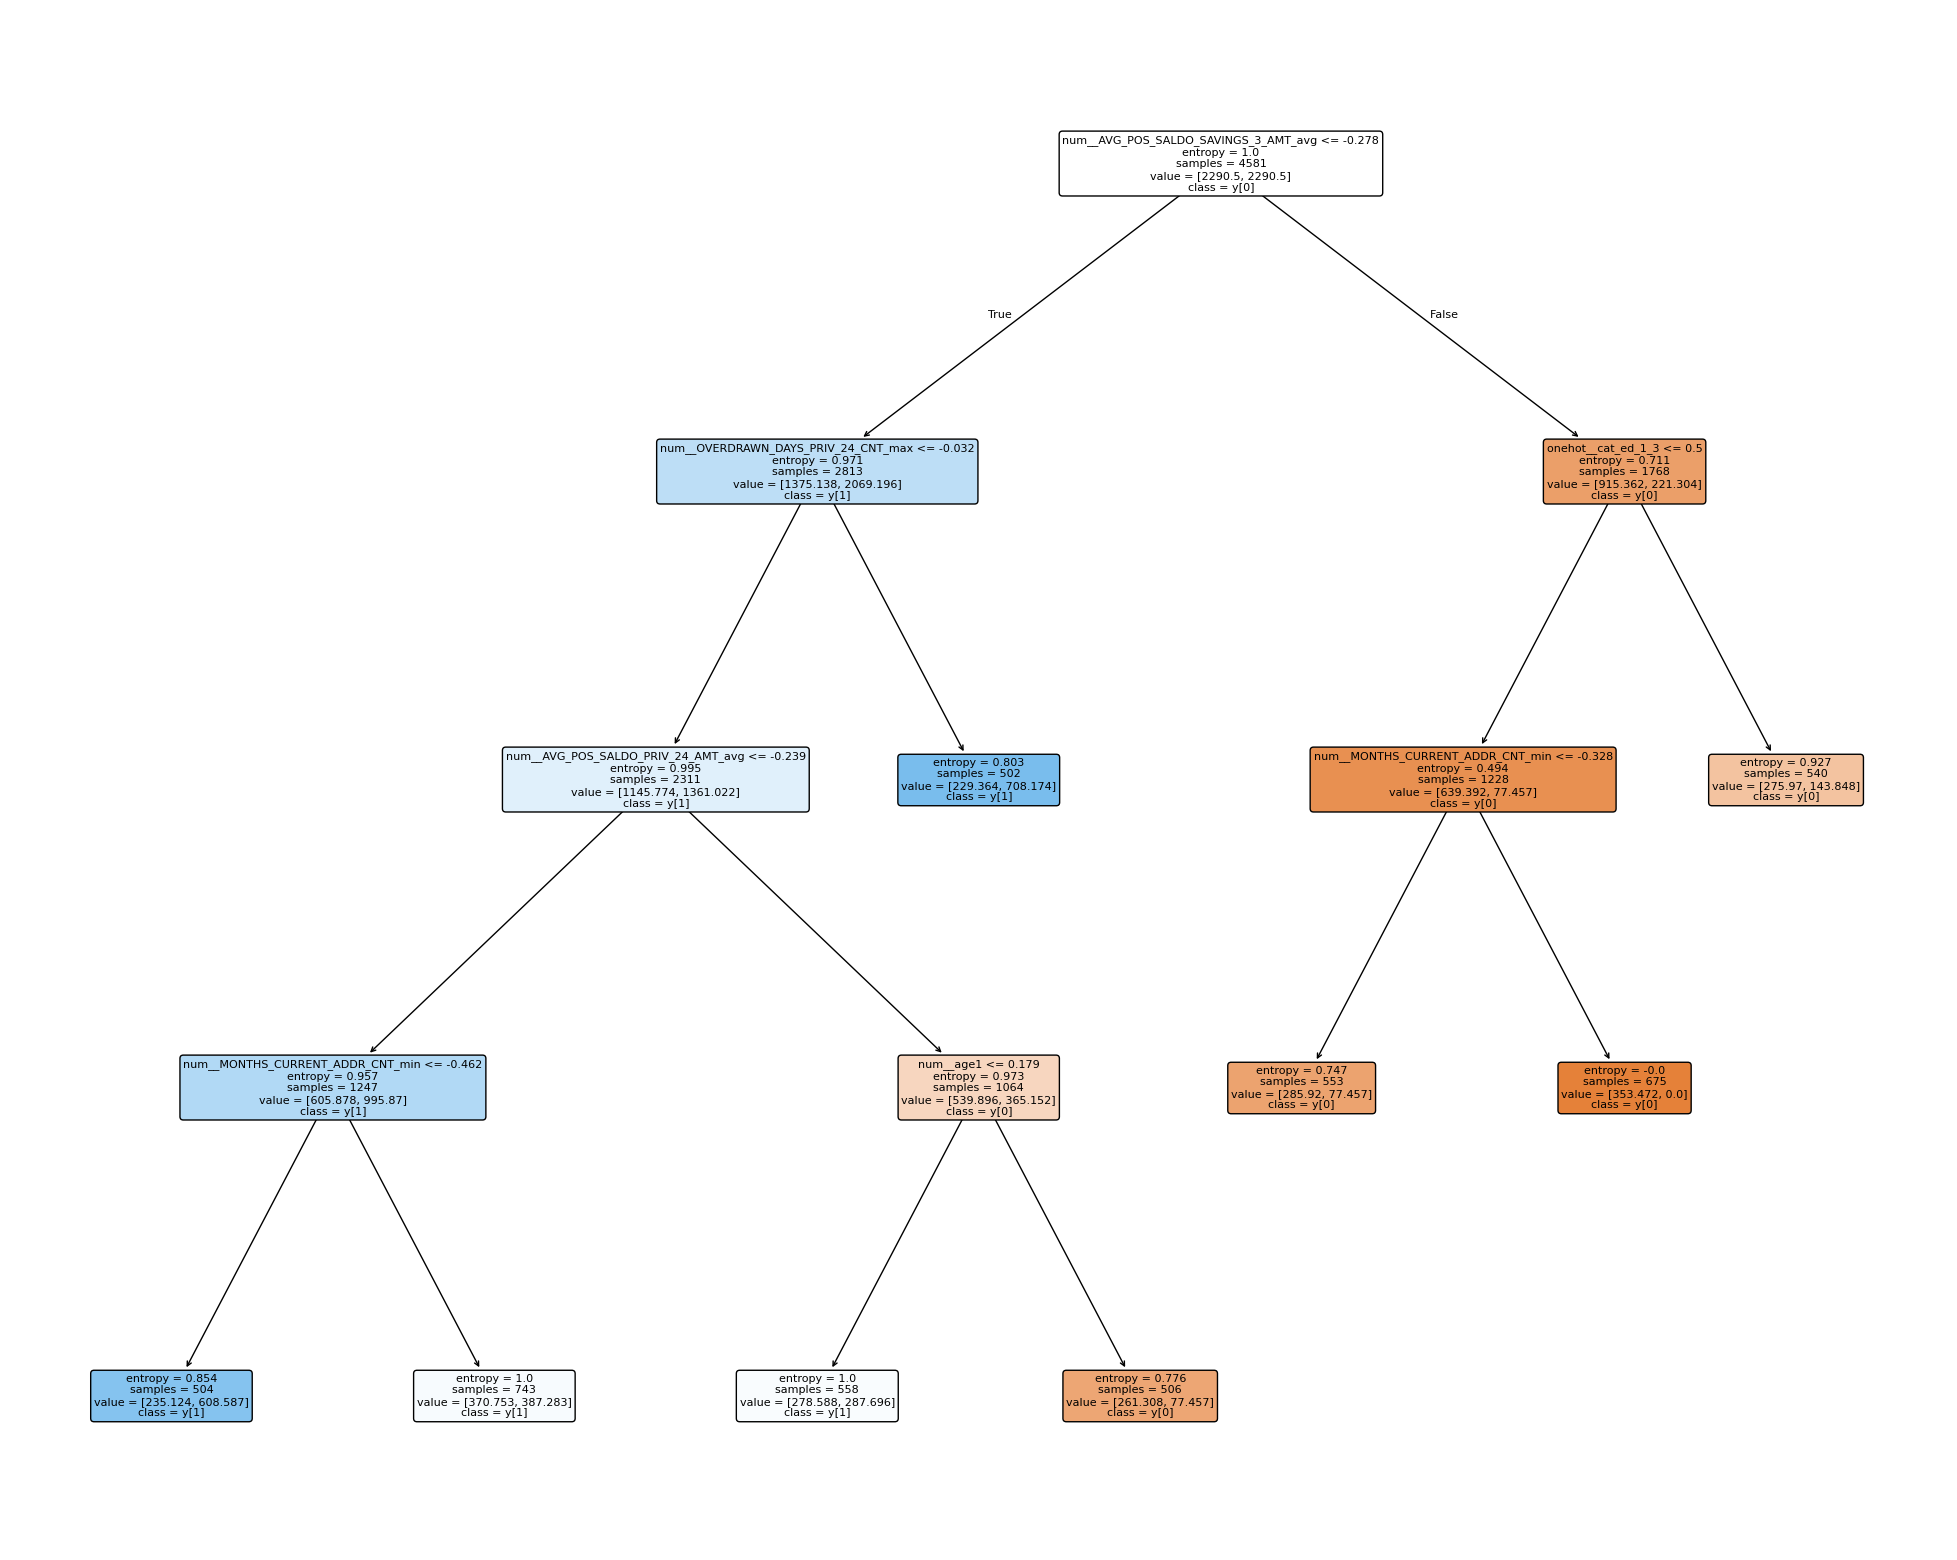

In [25]:

auc_value = []
N = np.arange(1,500, 1)
from sklearn import tree
for n in N:
    clf = tree.DecisionTreeClassifier(criterion='entropy', min_samples_leaf = n, class_weight= 'balanced' ,random_state = 0)
    clf = clf.fit(X_train_transformed, y_train)
    probs_val = clf.predict_proba(X_val_transformed)[:,1]
    auc_value.append(roc_auc_score(y_val, probs_val))

print("Grid search ended")
index_maximal_auc=np.argmax(auc_value)
n_optimal=N[index_maximal_auc]
print("The optimal number of leaf size is %i" %n_optimal)
#auc = []
#for i in range (1,100):
classifier = DecisionTreeClassifier(criterion = 'entropy',min_samples_leaf = n_optimal ,class_weight= 'balanced', random_state = 0)
classifier.fit(X_train_transformed, y_train)

# make predictions on validation set
y_pred = classifier.predict(X_val_transformed)
y_pred_prob = classifier.predict_proba(X_val_transformed)[:,1]#TODO
'''
    auc.append(roc_auc_score(y_val,y_val_scores)) #to find best class weight

max_auc = max(auc)
print (auc.index(max_auc))
'''
# calculate the accuracy on validation data
cm = confusion_matrix(y_val,y_pred)
print(cm)

accuracy_val = accuracy_score(y_val,y_pred)#TODO
print("Accuracy:" , accuracy_val)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

# AUC value on validation data
AUC_val = roc_auc_score(y_val,y_pred_prob)#TODO
print("AUC:" , AUC_val)

# visualize the tree 
from sklearn.tree import plot_tree
plt.figure(figsize=(25,20))  # Set the size of the plot
plot_tree(clf, filled=True, feature_names=X_train_transformed_df.columns, class_names=True, rounded=True, fontsize=8)
plt.show()


### Random Forest

This model is often strong in structured tabular data, which makes it a relevant benchmark for credit scoring.

Random Forest combines multiple decision trees to reduce variance and improve robustness.

In [26]:

# Train random forest and get feature importances
model = RandomForestClassifier(random_state=42, class_weight = 'balanced', criterion='entropy')
model.fit(X_train_transformed, y_train)


y_pred = classifier.predict(X_val_transformed)
y_proba = classifier.predict_proba(X_val_transformed)[:,1]

print ('confusion matrix')
cm = confusion_matrix(y_val, y_pred)
print(cm)

accuracy = accuracy_score(y_val, y_pred)
print ('accuracy:', accuracy)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

AUC_val = roc_auc_score(y_val, y_proba)
print ('AUC:', AUC_val)

importances = model.feature_importances_
# Display feature importances
feature_importances_rf = pd.Series(importances, index=X_train_transformed_df.columns).sort_values(ascending= False)
print(feature_importances_rf.head(30))


confusion matrix
[[963 502]
 [ 13  50]]
accuracy: 0.6629581151832461
Recall: 0.7936507936507936
F1 Score: 0.16260162601626016
precision: 0.09057971014492754
AUC: 0.7832114415732163
num__MONTHS_CURRENT_ADDR_CNT_min            0.018792
num__age_at_maturity                        0.018671
num__AVG_POS_SALDO_SAVINGS_6_AMT_avg        0.016561
num__AVG_POS_SALDO_SAVINGS_1_AMT_avg        0.016077
num__SCR                                    0.015945
num__TTL_EMPLOYMENT_MONTHS_2_CNT_min        0.015868
num__TOTAL_EMPLOYMENT_MONTHS_CNT_min        0.015468
num__AVG_POS_SALDO_SAVINGS_3_AMT_avg        0.015415
num__AVG_POS_SALDO_SAVINGS_9_AMT_avg        0.015103
num__DSCR                                   0.014798
num__avg_age                                0.014572
num__age1                                   0.014359
num__AVG_POS_SALDO_PRIV_6_AMT_avg           0.013464
regression_impute__KPI_CASH_FLOW_AMT        0.013161
num__AVG_POS_SALDO_SAVINGS_24_AMT_avg       0.012978
regression_impute__PROFI

### Hyperparameter tuning for Random Forest

A grid search is used to test different tree depths, split rules, and leaf sizes to find the best-performing configuration for the validation set.

In [27]:
classifier = RandomForestClassifier(random_state=42, class_weight = 'balanced')


# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [None, 10, 20],  # Maximum tree depth
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples required at a leaf node
}

# Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    classifier,
    param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Fit the model
grid_search.fit(X_train_transformed_df, y_train)

# Best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

best_params = grid_search.best_params_

best_model = RandomForestClassifier(**best_params,random_state=42, class_weight = 'balanced')

# Retrain best model on combined train + validation set
X_train_val = pd.concat([X_train_transformed_df, X_val_transformed_df], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)
best_model.fit(X_train_val, y_train_val)

# Test set evaluation
y_test_pred = best_model.predict(X_test_transformed_df)
y_test_prob = best_model.predict_proba(X_test_transformed_df)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_prob)
conf_matrix = confusion_matrix(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print("\nFinal Test Metrics:")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC-AUC Score: 0.7989030140872557

Final Test Metrics:
ROC-AUC Score: 0.8096
Confusion Matrix:
[[1462    1]
 [  62    3]]
Accuracy: 0.9588
F1 Score: 0.0870
Precision: 0.7500
Recall: 0.0462

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1463
           1       0.75      0.05      0.09        65

    accuracy                           0.96      1528
   macro avg       0.85      0.52      0.53      1528
weighted avg       0.95      0.96      0.94      1528



In [28]:
# Test set evaluation
y_test_pred = best_model.predict(X_test_transformed_df)
y_test_prob = best_model.predict_proba(X_test_transformed_df)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_prob)
conf_matrix = confusion_matrix(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)

print("\nFinal Test Metrics:")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))


Final Test Metrics:
ROC-AUC Score: 0.8096
Confusion Matrix:
[[1462    1]
 [  62    3]]
Accuracy: 0.9588
F1 Score: 0.0870
Precision: 0.7500
Recall: 0.0462

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1463
           1       0.75      0.05      0.09        65

    accuracy                           0.96      1528
   macro avg       0.85      0.52      0.53      1528
weighted avg       0.95      0.96      0.94      1528



### XGBoost

Here it is tested as a more advanced benchmark against the simpler models and feature selection variants.

XGBoost is a high-performing gradient boosting algorithm that often works extremely well on tabular classification tasks.

In [29]:
from xgboost import XGBClassifier

classifier = XGBClassifier(eval_metric='auc', base_score=0.04, random_state=42)


# Fit the model
classifier.fit(X_train_transformed_df, y_train)

# Evaluate on validation set
y_val_pred = classifier.predict(X_val_transformed_df)
y_val_prob = classifier.predict_proba(X_val_transformed_df)[:, 1]

# Compute Metrics
roc_auc = roc_auc_score(y_val, y_val_prob)
conf_matrix = confusion_matrix(y_val, y_val_pred)
accuracy = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)

# Print metrics
print("Validation Metrics:")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


# Evaluate on the test set
y_test_pred = classifier.predict(X_test_transformed_df)
y_test_prob = classifier.predict_proba(X_test_transformed_df)[:, 1]

print('-'*5)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")
print("\nTest Metrics:")
print(classification_report(y_test, y_test_pred))

Validation Metrics:
ROC-AUC Score: 0.8257
Confusion Matrix:
[[1463    2]
 [  57    6]]
Accuracy: 0.9614
F1 Score: 0.1690
Precision: 0.7500
Recall: 0.0952
-----
ROC-AUC Score: 0.7987

Test Metrics:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1463
           1       0.70      0.11      0.19        65

    accuracy                           0.96      1528
   macro avg       0.83      0.55      0.58      1528
weighted avg       0.95      0.96      0.95      1528



### XGBoost with feature selection

This step evaluates whether reducing the feature set improves generalization. Mutual information is used to identify the variables that contribute the most to class separation.

In [30]:
from sklearn.feature_selection import mutual_info_classif

# One-hot encoded features and categorical target
mutual_info = mutual_info_classif(X_train_transformed_df, y_train)

# Display results

mutual_info_df = pd.DataFrame({
    "Feature": X_train_transformed_df.columns,
    "Mutual Information": mutual_info
}).sort_values(by="Mutual Information", ascending=False)
#print(mutual_info_df)
significant = mutual_info_df[mutual_info_df['Mutual Information'] > 0]

In [31]:
significant1 = significant['Feature']
mutual_info_df.head(10)

,Feature,Mutual Information
334,num__AVG_POS_SALDO_PRIV_6_AMT_avg,0.011957
344,num__AVG_POS_SALDO_SAVINGS_24_AMT_avg,0.011195
345,num__AVG_POS_SALDO_SAVINGS_3_AMT_avg,0.010925
412,num__TOT_DOM_EXC_CRE_EXT_PRIV_CNT_max,0.010791
346,num__AVG_POS_SALDO_SAVINGS_6_AMT_avg,0.010057
336,num__AVG_POS_SALDO_PROF_12_AMT_avg,0.010009
450,num__SCR,0.009868
10,regression_impute__KPI_CASH_FLOW_AMT,0.009697
300,num__APPLIED_AMT,0.009673
299,num__APPLICANTS_CNT,0.009399


In [32]:
from xgboost import XGBClassifier

classifier = XGBClassifier(eval_metric='auc', base_score=0.04, random_state=42)


# Fit the model
classifier.fit(X_train_transformed_df[significant1], y_train)

# Evaluate on validation set
y_val_pred = classifier.predict(X_val_transformed_df[significant1])
y_val_prob = classifier.predict_proba(X_val_transformed_df[significant1])[:, 1]

# Compute Metrics
roc_auc = roc_auc_score(y_val, y_val_prob)
conf_matrix = confusion_matrix(y_val, y_val_pred)
accuracy = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)

# Print metrics
print("Validation Metrics:")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


# Evaluate on the test set
y_test_pred = classifier.predict(X_test_transformed_df[significant1])
y_test_prob = classifier.predict_proba(X_test_transformed_df[significant1])[:, 1]

print('-'*5)
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_prob):.4f}")
print("\nTest Metrics:")
print(classification_report(y_test, y_test_pred))

Validation Metrics:
ROC-AUC Score: 0.8247
Confusion Matrix:
[[1463    2]
 [  57    6]]
Accuracy: 0.9614
F1 Score: 0.1690
Precision: 0.7500
Recall: 0.0952
-----
ROC-AUC Score: 0.8112

Test Metrics:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1463
           1       0.60      0.09      0.16        65

    accuracy                           0.96      1528
   macro avg       0.78      0.54      0.57      1528
weighted avg       0.95      0.96      0.94      1528



### Lasso regularization

Lasso is used to identify the most important predictors by shrinking some coefficients to zero. This is helpful for simplifying the model and understanding which features remain relevant.

In [33]:

#lasso
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

#Initialize Lasso model 
lasso = Lasso(alpha=0.01)

#Fit the Lasso model
lasso.fit(X_train_transformed,y_train)
#Get the coefficiets of the features
coefficients = lasso.coef_
#Display the features and their importance
feature_importance = pd.DataFrame({
    "Feature": X_train_transformed_df.columns,
    "Coefficient":coefficients
}).sort_values(by="Coefficient", key = abs, ascending= False)
print("Selected Features:")
print(feature_importance[feature_importance["Coefficient"]!=0])

Selected Features:
                                      Feature   Coefficient
373       num__OVERDRAWN_DAYS_PRIV_12_CNT_max  8.861937e-03
447                                 num__DSCR  8.088091e-03
355       num__MONTHLY_RENTAL_CHARGES_AMT_max  6.743028e-03
399      num__TOT_DEB_INTEREST_PRIV_1_AMT_max  5.801363e-03
384                 num__SAVINGS_OPEN_CNT_max -3.926976e-03
357          num__MONTHS_CURRENT_ADDR_CNT_min -3.668170e-03
347      num__AVG_POS_SALDO_SAVINGS_9_AMT_avg -2.245938e-03
0               median_fill__BEH_SCORE_AVG_A1 -2.143122e-03
374       num__OVERDRAWN_DAYS_PRIV_24_CNT_max  1.761946e-03
441                                 num__age2 -1.712168e-03
440                                 num__age1 -1.054556e-03
454                 num__overdrawn_days12priv  3.669446e-04
376        num__OVERDRAWN_DAYS_PROF_3_CNT_max  1.161378e-04
412     num__TOT_DOM_EXC_CRE_EXT_PRIV_CNT_max -7.700348e-05
463                              num__avg_age -3.344822e-05
11   regression_imput

### HistGradientBoostingClassifier

The model is tuned using class weights and selected features to maximize predictive power on the validation data.

This is the final model family selected for the credit score pipeline. It is well suited to tabular data and handles non-linear effects while remaining robust with class imbalance.

In [34]:
classifier = HistGradientBoostingClassifier(
        class_weight = 'balanced',  # Automatically balances classes
        l2_regularization = 10,
        learning_rate = 0.2,
        max_depth = 7, 
        max_iter = 100, 
        min_samples_leaf = 50,
        random_state = 42           # Ensures reproducibility
    )

In [35]:
classifier.fit(X_train_transformed_df, y_train)

HistGradientBoostingClassifier(class_weight='balanced', l2_regularization=10,
                               learning_rate=0.2, max_depth=7,
                               min_samples_leaf=50, random_state=42)

### Generate validation predictions

Once the final model is trained, we generate probability scores and class predictions on the validation set. These results are used to assess whether the model is useful in a real credit decision context.

In [36]:
# Predicting the val set results
y_pred = classifier.predict(X_val_transformed_df)
y_proba = classifier.predict_proba(X_val_transformed_df)[:,1]

### Evaluate model performance

This section calculates the confusion matrix, accuracy, recall, precision, F1-score, and ROC-AUC. In credit risk modelling, recall is especially important because failing to identify a risky borrower can be costly.

In [37]:
print ('confusion matrix')
cm = confusion_matrix(y_val, y_pred)
print(cm)

accuracy = accuracy_score(y_val, y_pred)
print ('accuracy:', accuracy)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

AUC_val = roc_auc_score(y_val, y_proba)
print ('AUC_val', AUC_val)

confusion matrix
[[1446   19]
 [  49   14]]
accuracy: 0.9554973821989529
Recall: 0.2222222222222222
F1 Score: 0.2916666666666667
precision: 0.42424242424242425
AUC_val 0.8381277425646027


### Feature importance analysis

After selecting the best model, we estimate which variables contribute most to the predictions. This is useful for understanding which borrower characteristics drive default risk and for validating that the model is behaving in a financially plausible way.

In [38]:
from sklearn.inspection import permutation_importance
# Calculate permutation importance
perm_importance = permutation_importance(classifier, X_val_transformed_df, y_val, n_repeats=5, random_state=42)

feature_importance = pd.DataFrame({
    'Feature': X_train_transformed_df.columns,
    'Importance': perm_importance.importances_mean
})

# Sort by importance (descending)
sorted_features_hgb = feature_importance.sort_values(by='Importance',key= abs, ascending=False)

print(sorted_features_hgb.head(5))


                                  Feature  Importance
336    num__AVG_POS_SALDO_PROF_12_AMT_avg   -0.003272
427  num__TTL_EMPLOYMENT_MONTHS_2_CNT_min   -0.002880
383      num__POSIT_TRANS_SAVINGS_CNT_avg    0.002356
374   num__OVERDRAWN_DAYS_PRIV_24_CNT_max   -0.002094
216                  onehot__cat_mar_1_02   -0.001963


### Optimise the feature subset

This stage tests different numbers of top-ranked variables and selects the subset that maximizes validation ROC-AUC. The goal is to retain only the most informative features and avoid noise from weak predictors.

In [39]:
max_auc = 0
max_i = 0


for i in range(15,sorted_features_hgb[sorted_features_hgb['Importance'] != 0].shape[0]+5):
    # Filter top features (e.g., top i most important features)
    top_features = list(sorted_features_hgb['Feature'].head(i))

    # Filter the transformed dataset using the indices
    X_train_top = X_train_transformed_df[top_features]

    X_val_top = X_val_transformed_df[top_features]
    

    # Retrain the model with the reduced feature set
    model_reduced = HistGradientBoostingClassifier(
        class_weight = 'balanced',  # Automatically balances classes
        l2_regularization = 10,
        learning_rate = 0.2,
        max_depth = 7, 
        max_iter = 100, 
        min_samples_leaf = 50,
        random_state = 42           # Ensures reproducibility
        )
    

    model_reduced.fit(X_train_top, y_train)

    # Evaluate the model
    y_pred = model_reduced.predict(X_val_top)
    y_pred_prob = model_reduced.predict_proba(X_val_top)[:, 1]

    roc_auc = roc_auc_score(y_val, y_pred_prob)
    print(i, roc_auc)
    if (roc_auc> max_auc):
        max_auc = roc_auc
        max_i = i

print ('max')
print (max_i, max_auc)#max i is the number of features for which we get the highest AUC. After running it we got that optimal features are 137. 


15 0.7799826642830056
16 0.7748740451812124
17 0.7797659678205753
18 0.7856384419524352
19 0.7737959802806218
20 0.7451487079473427
21 0.766525813966087
22 0.7747602795384365
23 0.7814562002275313
24 0.7881467035050652
25 0.8165881141990357
26 0.7849937699767051
27 0.7933257489571482
28 0.8049081748740451
29 0.81124654640013
30 0.7950701554797117
31 0.8248009101251423
32 0.8104230998428952
33 0.8128284305758708
34 0.8154612925943985
35 0.8211929140256784
36 0.8240641421528794
37 0.8253751557505824
38 0.8203694674684435
39 0.8188850967007963
40 0.8312909691749282
41 0.8204019719378082
42 0.8147678639146215
43 0.8053307329757842
44 0.8192209762175633
45 0.82858226339455
46 0.8174332304025137
47 0.8131859797388807
48 0.8131751449157593
49 0.816447261498456
50 0.8209112086245192
51 0.8283113928165122
52 0.8110623544070643
53 0.8105856221897177
54 0.8043881033642125
55 0.8232298607725228
56 0.8096321577550247
57 0.8190692886938621
58 0.8226881196164472
59 0.8202177799447424
60 0.82814887046

### Tune class weights for imbalance handling

Because default is typically the minority class in credit portfolios, this section tests different class weight settings to improve the model's sensitivity to defaults without sacrificing stability.

In [40]:
top_features = list(sorted_features_hgb['Feature'].head(max_i))

X_train_top = X_train_transformed_df[top_features]
X_val_top = X_val_transformed_df[top_features]
# lets try changing class weight
best_i = 0
best_auc = 0
for i in range (1,99):

    #This is the best model so far. It gives an AUC of 0.8593
    #best_i is the optimal  weight for the below classifier and after running it we get 28 as the best_i
    model_reduced = HistGradientBoostingClassifier(
        class_weight = {0: 1, 1: i},  
        l2_regularization = 10,
        learning_rate = 0.2,
        max_depth = 7, 
        max_iter = 100, 
        min_samples_leaf = 50,
        random_state = 42           # Ensures reproducibility
        ) 
    
    model_reduced.fit(X_train_top, y_train)
    
    # Evaluate the model
    y_pred = model_reduced.predict(X_val_top)
    y_pred_prob = model_reduced.predict_proba(X_val_top)[:, 1]
    
    
    #print ('confusion matrix')
    cm = confusion_matrix(y_val, y_pred)
    #print(cm)
    
    accuracy = accuracy_score(y_val, y_pred)
    #print ('accuracy:', accuracy)
    
    # Recall
    recall = recall_score(y_val, y_pred)
    #print("Recall:", recall)
    
    # F1 Score
    f1 = f1_score(y_val, y_pred)
    #print("F1 Score:", f1)
    
    #precision
    precision = precision_score(y_val, y_pred)
    #print ('precision:', precision)
    
    AUC_val = roc_auc_score(y_val, y_pred_prob)
    #print ('AUC_val', AUC_val)
    print (i, 'AUC_val', AUC_val)
    if (AUC_val > best_auc):
        best_auc = AUC_val
        best_i = i

print ('max')
print (best_i, best_auc)

1 AUC_val 0.8466222438918685
2 AUC_val 0.8415732163172436
3 AUC_val 0.8573270491359228
4 AUC_val 0.8526247359011864
5 AUC_val 0.8349314697437564
6 AUC_val 0.8391137114686602
7 AUC_val 0.8534481824584214
8 AUC_val 0.842743377214367
9 AUC_val 0.8372067825992742
10 AUC_val 0.8357440814778698
11 AUC_val 0.8494176282572186
12 AUC_val 0.8510103472560809
13 AUC_val 0.8411831626848691
14 AUC_val 0.8481932932444878
15 AUC_val 0.8464055474294382
16 AUC_val 0.8533398342272063
17 AUC_val 0.8417357386640664
18 AUC_val 0.8376185058778916
19 AUC_val 0.8400455062571104
20 AUC_val 0.8511403651335392
21 AUC_val 0.8438268595265181
22 AUC_val 0.8501002221138739
23 AUC_val 0.8396554526247358
24 AUC_val 0.8466005742456254
25 AUC_val 0.8385936399588277
26 AUC_val 0.8581071564006717
27 AUC_val 0.8422558101738988
28 AUC_val 0.8603066254943387
29 AUC_val 0.8483016414757029
30 AUC_val 0.8387344926594074
31 AUC_val 0.840013001787746
32 AUC_val 0.8329053578200336
33 AUC_val 0.8314751611679939
34 AUC_val 0.84055474

## 6. Final model for scoring

This section defines the final model configuration to be used on the unseen scoring dataset.

The selected feature subset and class-weight setting were chosen from the validation analysis to maximize discrimination between default and non-default borrowers.

In [41]:
top_features = list(sorted_features_hgb['Feature'].head(max_i))

X_train_top = X_train_transformed_df[top_features]
X_val_top = X_val_transformed_df[top_features]

#the variables above are defined before, just putting it here for ease of reference

model_reduced = HistGradientBoostingClassifier(
    class_weight = 'balanced',  
    l2_regularization = 10,
    learning_rate = 0.2,
    max_depth = 7, 
    max_iter = 100, 
    min_samples_leaf = 50,
    random_state = 42           # Ensures reproducibility
    ) 

model_reduced.fit(X_train_top, y_train)

# Evaluate the model
y_pred = model_reduced.predict(X_val_top)
y_pred_prob = model_reduced.predict_proba(X_val_top)[:, 1]


print ('confusion matrix')
cm = confusion_matrix(y_val, y_pred)
print(cm)

accuracy = accuracy_score(y_val, y_pred)
print ('accuracy:', accuracy)

# Recall
recall = recall_score(y_val, y_pred)
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_val, y_pred)
print("F1 Score:", f1)

#precision
precision = precision_score(y_val, y_pred)
print ('precision:', precision)

AUC_val = roc_auc_score(y_val, y_pred_prob)
print ('AUC_val', AUC_val)


confusion matrix
[[1446   19]
 [  48   15]]
accuracy: 0.956151832460733
Recall: 0.23809523809523808
F1 Score: 0.30927835051546393
precision: 0.4411764705882353
AUC_val 0.8660924210412265


## 7. Score the unseen application dataset

The trained model is now applied to the scoring dataset, which contains the new loan applications without labels. The model produces a probability score representing each borrower's estimated default risk.

In [42]:
# import the scoring dataset
scoring_dataset = pd.read_csv(r"DSC_scoring.csv")
print(scoring_dataset.shape)
print(scoring_dataset.info())
# print(scoring_dataset.head())

(7638, 173)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7638 entries, 0 to 7637
Columns: 173 entries, ACTIVE_CREDITS_FLG to birth_dt_A3
dtypes: float64(150), int64(8), object(15)
memory usage: 10.1+ MB
None


In [43]:
# preprocess scoring data in the way that 100% aligns with methods used for training set to ensure the same data structure
scoring_dataset['APPLICATION_DT'] = pd.to_datetime(scoring_dataset['APPLICATION_DT']) #application date
scoring_dataset['MATURITY_DT'] = pd.to_datetime(scoring_dataset['MATURITY_DT']) # maturity date
scoring_dataset['birth_dt_A1'] = pd.to_datetime(scoring_dataset['birth_dt_A1']) # YOB_1
scoring_dataset['birth_dt_A2'] = pd.to_datetime(scoring_dataset['birth_dt_A2']) # YOB_2
scoring_dataset['birth_dt_A3'] = pd.to_datetime(scoring_dataset['birth_dt_A3']) # YOB_3


scoring_dataset["tenure"] = scoring_dataset.apply(
    lambda row: (row['MATURITY_DT'] - row['APPLICATION_DT']).days / 365.25, axis=1
)
scoring_dataset["age1"] = scoring_dataset.apply(
    lambda row: (row['APPLICATION_DT'] - row['birth_dt_A1']).days / 365.25, axis=1
)
scoring_dataset["age2"] = scoring_dataset.apply(
    lambda row: (row['APPLICATION_DT'] - row['birth_dt_A2']).days / 365.25, axis=1
)
scoring_dataset["age3"] = scoring_dataset.apply(
    lambda row: (row['APPLICATION_DT'] - row['birth_dt_A3']).days / 365.25, axis=1
)

scoring_dataset['application_month'] = scoring_dataset.apply(
    lambda row: (row['APPLICATION_DT']).month, axis=1
    )

scoring_dataset.drop(columns=['year','birth_dt_A1', 'birth_dt_A2', 'birth_dt_A3', 'MATURITY_DT', 'APPLICATION_DT', 'APPLICATION_BY_EMPLOYEE_FLG'], inplace=True)

scoring_dataset[["cat_profession_1", "cat_profession_2"]] = scoring_dataset["PROFESSION_CAT"].str.split("-", expand=True)
scoring_dataset[["cat_ed_1", "cat_ed_2"]] = scoring_dataset["CAT_EDUCATION_LEVEL_CD"].str.split("-", expand=True)
scoring_dataset[["cat_empl_1", "cat_empl_2"]] = scoring_dataset["EMPLOYMENT_STATUS_CD"].str.split("-", expand=True)
scoring_dataset[["cat_res_1", "cat_res_2"]] = scoring_dataset["CAT_RESIDENT_STATUS_CD"].str.split("-", expand=True)
scoring_dataset[["cat_inc_src_1", "cat_inc_src_2"]] = scoring_dataset["CAT_INCOME_SRC_CD"].str.split("-", expand=True)
scoring_dataset[["cat_inc_rep_1", "cat_inc_rep_2"]] = scoring_dataset["CAT_REP_INCOME_SRC_CD"].str.split("-", expand=True)
scoring_dataset[["cat_mar_1", "cat_mar_2"]] = scoring_dataset["COMB_MARITAL_STATUS"].str.split("-", expand=True)


scoring_dataset.drop(columns=['CREDIT_TYPE_CD', "PROFESSION_CAT",'CAT_EDUCATION_LEVEL_CD','EMPLOYMENT_STATUS_CD', "CAT_RESIDENT_STATUS_CD","CAT_INCOME_SRC_CD", "CAT_REP_INCOME_SRC_CD",'COMB_MARITAL_STATUS','TOT_DOM_EXC_CRE_INT_PRIV_AMT_max','TOT_DOM_EXC_CRE_INT_PRIV_CNT_max','TOT_DOM_EXC_CRE_INT_PROF_AMT_max','TOT_DOM_EXC_CRE_INT_PROF_CNT_max'], inplace=True)
scoring_dataset['is_be'] = np.where(scoring_dataset['nationality_A1'] == 'B', 1, 0) 

#fill missing values
scoring_dataset['mnths_in_business_flg'] = np.where(pd.notna(scoring_dataset['MTHS_IN_BUSINESS_CNT']), 1, 0) 
scoring_dataset.drop(columns=['MTHS_IN_BUSINESS_CNT'], inplace=True)

scoring_dataset['mnths_in_be'] = np.where(pd.notna(scoring_dataset['MONTHS_IN_BELGIUM_CNT_min']), 1, 0) 
scoring_dataset.drop(columns=['MONTHS_IN_BELGIUM_CNT_min'], inplace=True)

#before filling the 'MORTGAGE_ON_REAL_ESTATE_FLG', we need to perform a check
#when feature 'REAL_ESTATE_VALUE_AMT' has a value and 'MORTGAGE_ON_REAL_ESTATE_FLG' is NaN, we make it 1 else we leave it as is
scoring_dataset['MORTGAGE_ON_REAL_ESTATE_FLG'] = np.where(scoring_dataset['MORTGAGE_ON_REAL_ESTATE_FLG'].isna() & scoring_dataset['REAL_ESTATE_VALUE_AMT'].notna(), 1, scoring_dataset['MORTGAGE_ON_REAL_ESTATE_FLG'])
#when feature 'REAL_ESTATE_VALUE_AMT' has a value and 'MORTGAGE_ON_REAL_ESTATE_FLG' is 0, we make it 1 else we leave it as is
scoring_dataset['MORTGAGE_ON_REAL_ESTATE_FLG'] = np.where(scoring_dataset['MORTGAGE_ON_REAL_ESTATE_FLG'] == 0 & scoring_dataset['REAL_ESTATE_VALUE_AMT'].notna(), 1, scoring_dataset['MORTGAGE_ON_REAL_ESTATE_FLG'])

#to adrress DataFrame fragmented warning, we write to the below df, and at the end concat with original df
scoring_dataset_tmp = pd.DataFrame()
#Debt-to-income
scoring_dataset_tmp['dti_1'] = (scoring_dataset['APPLIED_AMT']+scoring_dataset['OTH_BANKS_CREDITS_AMT']) /scoring_dataset['ANNUAL_INCOME_AMT_avg']
scoring_dataset_tmp['dti_2'] = (scoring_dataset['APPLIED_AMT']+scoring_dataset['TOT_OPEN_CREDITS_AMT']) /scoring_dataset['ANNUAL_INCOME_AMT_avg']
scoring_dataset_tmp['dti_3'] = np.where(scoring_dataset['OTH_BANKS_CREDITS_AMT'] < scoring_dataset['TOT_OPEN_CREDITS_AMT'], scoring_dataset_tmp['dti_2'], scoring_dataset_tmp['dti_1']) # if condition is true, I want to keep dti_2, else keep dti_1

#df_tmp['dti'] = (df['APPLIED_AMT']+df[['OTH_BANKS_CREDITS_AMT', 'TOT_OPEN_CREDITS_AMT']].max(axis=1)) /df['ANNUAL_INCOME_AMT_avg']

#Loan-to-Value Ratio(LTV)
scoring_dataset_tmp['LTV']=scoring_dataset['APPLIED_AMT']/scoring_dataset['COLLATERAL_AMT']

#Debt service coverage ratio
scoring_dataset_tmp['DSCR']=scoring_dataset['KPI_CASH_FLOW_AMT']/scoring_dataset['KPI_REPAYM_CAP_AMT']

#Credit utilization rate
scoring_dataset_tmp['CUR1']=scoring_dataset['TOT_OPEN_CREDITS_AMT']/scoring_dataset['TOT_CRED_LINE_COREPRIV_AMT_max']
scoring_dataset_tmp['CUR2']=scoring_dataset['TOT_OPEN_CREDITS_AMT']/scoring_dataset['TOT_CRED_LINE_COREPROF_AMT_max']

#SAVINGS CUSHION RATE
scoring_dataset_tmp['SCR']=scoring_dataset['AVG_POS_SALDO_SAVINGS_12_AMT_avg']/scoring_dataset['APPLIED_AMT']

#PROPORTION OF OVERDRAWN DAYS

scoring_dataset_tmp['overdrawn_days3priv']= scoring_dataset['OVERDRAWN_DAYS_PRIV_3_CNT_max']/3
scoring_dataset_tmp['overdrawn_days6priv']= scoring_dataset['OVERDRAWN_DAYS_PRIV_6_CNT_max']/6
scoring_dataset_tmp['overdrawn_days9priv']= scoring_dataset['OVERDRAWN_DAYS_PRIV_9_CNT_max']/9
scoring_dataset_tmp['overdrawn_days12priv']= scoring_dataset['OVERDRAWN_DAYS_PRIV_12_CNT_max']/12
scoring_dataset_tmp['overdrawn_days24priv']= scoring_dataset['OVERDRAWN_DAYS_PRIV_24_CNT_max']/24
scoring_dataset_tmp['overdrawn_days3prof']= scoring_dataset['OVERDRAWN_DAYS_PROF_3_CNT_max']/3
scoring_dataset_tmp['overdrawn_days6prof']= scoring_dataset['OVERDRAWN_DAYS_PROF_6_CNT_max']/6
scoring_dataset_tmp['overdrawn_days9prof']= scoring_dataset['OVERDRAWN_DAYS_PROF_9_CNT_max']/9
scoring_dataset_tmp['overdrawn_days12prof']= scoring_dataset['OVERDRAWN_DAYS_PROF_12_CNT_max']/12
scoring_dataset_tmp['overdrawn_days24prof']= scoring_dataset['OVERDRAWN_DAYS_PROF_24_CNT_max']/24

#Max Negative Balance/Income
scoring_dataset_tmp['Max_neg_balancetoincpriv']=scoring_dataset['AVG_NEG_SALDO_PRIV_12_AMT_max']/scoring_dataset['ANNUAL_INCOME_AMT_avg']
scoring_dataset_tmp['Max_neg_balancetoincprof']=scoring_dataset['AVG_NEG_SALDO_PROF_12_AMT_max']/scoring_dataset['ANNUAL_INCOME_AMT_avg']

#Average age 
scoring_dataset_tmp['avg_age']=scoring_dataset[['age1','age2','age3']].mean(axis=1)

#Dependents to Income Ratio
scoring_dataset_tmp['dependentstoinc']=scoring_dataset['DEPENDENTS_CNT_max']/scoring_dataset['ANNUAL_INCOME_AMT_avg']

scoring_dataset_tmp['age_at_maturity'] = np.where(scoring_dataset['FINANCIAL_PRODUCT_TYPE_CD'] == 'MTG', scoring_dataset['age1'] + scoring_dataset['tenure'], scoring_dataset['age1']) 


scoring_dataset = pd.concat([scoring_dataset,scoring_dataset_tmp],axis=1)
#some of the new variables (LTV for example) have been divided by 0, so we replace np.inf (infinity) with nan
scoring_dataset.replace({np.inf: np.nan}, inplace = True) 

scoring_dataset.replace({None: np.nan}, inplace = True)
scoring_dataset.replace({'': np.nan}, inplace = True)
scoring_dataset.replace({'NaN': np.nan}, inplace = True)
scoring_dataset["Nace_A1"] = scoring_dataset["Nace_A1"].astype(str)
scoring_dataset['nace'] = scoring_dataset['Nace_A1'].apply(lambda x: x[:2])
scoring_dataset['nace'] = np.where(scoring_dataset['nace']=='na','0',scoring_dataset['nace'])
scoring_dataset.drop(columns=['Nace_A1'], inplace=True)

#in the line above, we keep only the first two digits of the Nace classification

scoring_dataset['application_month'] = scoring_dataset['application_month'].astype(str)
scoring_dataset["Gender_A1"] = scoring_dataset["Gender_A1"].astype(str)
scoring_dataset["Gender_A2"] = scoring_dataset["Gender_A2"].astype(str)
scoring_dataset["Gender_A3"] = scoring_dataset["Gender_A3"].astype(str)
scoring_dataset["ACTIVE_CREDITS_FLG"] = scoring_dataset["ACTIVE_CREDITS_FLG"].astype(str)
scoring_dataset["MORTGAGE_ON_REAL_ESTATE_FLG"] = scoring_dataset["MORTGAGE_ON_REAL_ESTATE_FLG"].astype(str)
scoring_dataset["OTHER_REAL_ESTATE_FLG_max"] = scoring_dataset["OTHER_REAL_ESTATE_FLG_max"].astype(str)
scoring_dataset["EXP_WITH_CUSTOMER_CD"] = scoring_dataset["EXP_WITH_CUSTOMER_CD"].astype(str)

scoring_dataset['is_be'] = scoring_dataset['is_be'].astype(str)
scoring_dataset['mnths_in_business_flg'] = scoring_dataset['mnths_in_business_flg'].astype(str)
scoring_dataset['mnths_in_be'] = scoring_dataset['mnths_in_be'].astype(str)

In [44]:
#separate categorical from numerical columns
columns_to_encode = scoring_dataset.select_dtypes(include=['object']).columns
numerical_columns = [col for col in scoring_dataset if col not in columns_to_encode]

constant_columns = scoring_dataset[numerical_columns].loc[:, scoring_dataset[numerical_columns].std() == 0].columns
#print(f"Constant columns in train_num_df: {constant_columns}")
scoring_dataset.drop(columns=constant_columns, inplace=True)

columns_to_encode = scoring_dataset.select_dtypes(include=['object']).columns
numerical_columns = [col for col in scoring_dataset if col not in columns_to_encode]

In [45]:
# Combine into a column transformer
preprocessor = ColumnTransformer([
    ("median_fill", median_pipeline, cols_median),
    ("regression_impute", RegressionImputer(target_col=regressor_target, regressor_features=regressor_features), ['KPI_CASH_FLOW_AMT', 'PROFIT_BEFORE_TAX_AMT','ANNUAL_INCOME_AMT_avg']),
    #("zero_fill", zero_fill_imputer, numerical_columns),
    ("onehot", cat_imputer, columns_to_encode),
    #("woe_transform", woe_pipe, woe_cols),
    ("num", numerical_pipeline, numerical_columns)

], remainder="passthrough")


preprocessor.fit(X_train,y_train)
scoring_dataset_transformed = preprocessor.transform(scoring_dataset)
scoring_dataset_transformed_df = pd.DataFrame(
    scoring_dataset_transformed, 
    columns=preprocessor.get_feature_names_out(), 
)



In [46]:
print(scoring_dataset_transformed_df.shape)

# using the best model to predict
top_features = list(sorted_features_hgb['Feature'].head(max_i))    
scoring_dataset_w_top_features = scoring_dataset_transformed_df[top_features]

clf = HistGradientBoostingClassifier(
        class_weight = 'balanced',  # the best result is with balanced class_weight
        l2_regularization = 10,
        learning_rate = 0.2,
        max_depth = 7, 
        max_iter = 100, 
        min_samples_leaf = 50,
        random_state = 42           # Ensures reproducibility
        )
    
clf.fit(X_train_top, y_train)
y_pred = model_reduced.predict(scoring_dataset_w_top_features)
y_pred_prob = model_reduced.predict_proba(scoring_dataset_w_top_features)[:, 1]



(7638, 466)


## 8. Final output

The model's predicted default probabilities are exported to an Excel file so they can be reviewed by the credit risk team or used in downstream decisioning workflows.

This final output is the practical business artifact produced by the modelling pipeline.

In [47]:
# save the prediction
scoring_predictions = pd.DataFrame()
scoring_predictions['probabilities'] = y_pred_prob
# scoring_predictions['lables'] = y_pred
#scoring_predictions.index = scoring_predictions.index + 1

with pd.ExcelWriter('Group29_Konstantina_Die_Emilia_final.xlsx') as writer:
    scoring_predictions.to_excel(writer, sheet_name='predictions', index=True)